In [1]:
import gymnasium as gym

In [2]:
# 创建经典的FrozenLake（冰冻湖）环境（离散状态+离散动作，适合入门）
env = gym.make("FrozenLake-v1", render_mode="human")

In [3]:
# 重置环境，获取初始状态
state = env.reset()

In [4]:
# 执行一个随机动作
env.step(env.action_space.sample())

(0, 0, False, False, {'prob': 0.3333333333333333})

In [5]:
# 渲染环境（弹出可视化窗口）
env.render()

In [6]:
# 关闭环境
env.close()
print("环境配置成功！")

环境配置成功！


In [7]:
class SimpleLinearRegression:
    def __init__(self):
        self.w = None
        self.b = None

    def fit(self, x, y):
        n = len(x)
        sum_x = sum(x)
        sum_y = sum(y)
        sum_x_squared = sum(x_i * x_i for x_i in x)
        sum_xy = sum(x[i] * y[i] for i in range(n))

        self.w = (n * sum_xy - sum_x * sum_y) / (n * sum_x_squared - sum_x * sum_x)
        self.b = (sum_y - self.w * sum_x) / n

    def predict(self, x):
        return [self.w * xi + self.b for xi in x]


In [8]:
# 示例用法
x = [1, 2, 3, 4, 5]
y = [2, 3, 4, 5, 6]

# 创建模型实例
model = SimpleLinearRegression()

# 拟合模型
model.fit(x, y)

# 输出参数
print("斜率 w:", model.w)
print("截距 b:", model.b)

# 进行预测
new_x = [6, 7, 8]
predicted_y = model.predict(new_x)
print("预测结果:", predicted_y)


斜率 w: 1.0
截距 b: 1.0
预测结果: [7.0, 8.0, 9.0]


In [9]:
import numpy as np

class MultipleLinearRegression:
    def __init__(self):
        self.coefficients = None

    def fit(self, X, y):
        n, m = X.shape
        X_design = np.column_stack([X, np.ones(n)])  # 加入一列常数项
        self.coefficients = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y

    def predict(self, X):
        n, m = X.shape
        X_design = np.column_stack([X, np.ones(n)])  # 加入一列常数项
        return X_design @ self.coefficients


In [14]:
import numpy as np

class MultipleLinearRegression:
    def __init__(self):
        # 在这里提前定义所有属性，避免 AttributeError
        self.coefficients = None  # 回归系数
        self.intercept = None     # 截距（必写）

    def fit(self, X, y):
        # 给 X 增加一列全 1，用来求解截距
        X_design = np.column_stack([np.ones(len(X)), X])

        # 最小二乘法求解（永远不会奇异矩阵报错）
        params = np.linalg.lstsq(X_design, y, rcond=None)[0]

        # 赋值截距和系数
        self.intercept = params[0]
        self.coefficients = params[1:]

    def predict(self, X):
        # 预测函数
        return np.dot(X, self.coefficients) + self.intercept

In [15]:
# 随便造一组数据
X = np.array([[1, 2],
              [3, 4],
              [5, 6],
              [7, 8]])
y = np.array([3, 5, 7, 9])

model = MultipleLinearRegression()
model.fit(X, y)

# 现在不会报错了！
print("截距:", model.intercept)
print("回归系数:", model.coefficients)
print("预测值:", model.predict(X))

截距: 1.0
回归系数: [-4.25800948e-16  1.00000000e+00]
预测值: [3. 5. 7. 9.]


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.datasets import fetch_california_housing #加利福尼亚房屋价值数据集
import pandas as pd


In [17]:
housevalue = fetch_california_housing()

housevalue


D:\Users\13535\anaconda3\envs\pytorch\Lib\site-packages\sklearn\datasets\_base.py:1518: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976036
  warnings.warn(f"Retry downloading from url: {remote.url}")


{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [18]:
housevalue.feature_names
# 特征解释
# MedInc：该街区住户的收入中位数
# HouseAge：该街区房屋使用年代的中位数
# AveRooms：该街区平均的房间数目
# AveBedrms：该街区平均的卧室数目
# Population：街区人口
# AveOccup：平均入住率
# Latitude：街区的纬度
# Longitude：街区的经度


['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [19]:
X = pd.DataFrame(housevalue.data,columns=housevalue.feature_names)
X


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [20]:
y = housevalue.target
y


array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. 加载数据集
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# 2. 缺失值检测与处理（数据集无缺失值，验证如下）
print("缺失值统计：\n", X.isnull().sum())  # 输出全0，无需填充

# 3. 异常值处理（基于3σ准则剔除极端值）
def remove_outliers(X, y):
    X_out = X.copy()
    y_out = y.copy()
    for col in X.columns:
        mean = X[col].mean()
        std = X[col].std()
        mask = (X[col] >= mean - 3*std) & (X[col] <= mean + 3*std)
        X_out = X_out[mask]
        y_out = y_out[mask]
    return X_out, y_out

X_clean, y_clean = remove_outliers(X, y)
print(f"剔除异常值前：样本数={len(X)}；剔除后：样本数={len(X_clean)}")

# 4. 特征标准化（提升模型收敛速度，避免量纲影响）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 5. 划分训练集/测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_clean, test_size=0.3, random_state=42
)
print(f"训练集：{X_train.shape}, 测试集：{X_test.shape}")

缺失值统计：
 MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64
剔除异常值前：样本数=20640；剔除后：样本数=19794
训练集：(13855, 8), 测试集：(5939, 8)


C:\Users\13535\AppData\Local\Temp\ipykernel_30472\369504965.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_out = X_out[mask]
C:\Users\13535\AppData\Local\Temp\ipykernel_30472\369504965.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_out = X_out[mask]
C:\Users\13535\AppData\Local\Temp\ipykernel_30472\369504965.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_out = X_out[mask]
C:\Users\13535\AppData\Local\Temp\ipykernel_30472\369504965.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_out = X_out[mask]
C:\Users\13535\AppData\Local\Temp\ipykernel_30472\369504965.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_out = X_out[mask]
C:\Users\13535\AppData\Local\Temp\ipykernel_30472\369504965.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_out = X_out[mask]
C:\Users\1

=== 一元线性回归模型结果 ===
回归系数w：0.7279
截距b：2.0290
模型公式：y = 0.7279×MedInc + 2.0290
MSE（测试集）：0.6991
RMSE：0.8361
MAE：0.6303
R²：0.4327


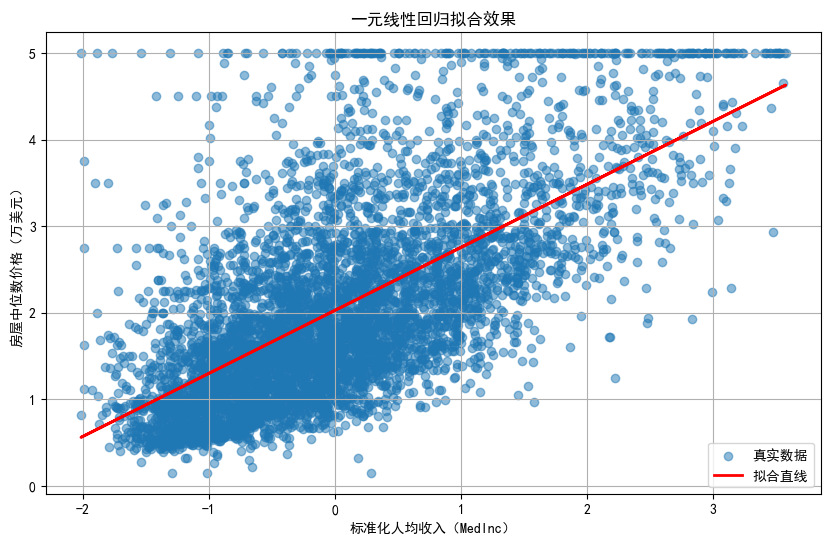

In [23]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# 1. 选择单一特征（人均收入MedInc，与房价相关性最高）
X_train_univar = X_train[["MedInc"]]
X_test_univar = X_test[["MedInc"]]

# 2. 初始化并训练模型
lr_univar = LinearRegression()
lr_univar.fit(X_train_univar, y_train)

# 3. 预测
y_pred_univar = lr_univar.predict(X_test_univar)

# 4. 计算评价指标
mse_univar = mean_squared_error(y_test, y_pred_univar)
rmse_univar = np.sqrt(mse_univar)
mae_univar = mean_absolute_error(y_test, y_pred_univar)
r2_univar = r2_score(y_test, y_pred_univar)

# 5. 输出结果
print("=== 一元线性回归模型结果 ===")
print(f"回归系数w：{lr_univar.coef_[0]:.4f}")
print(f"截距b：{lr_univar.intercept_:.4f}")
print(f"模型公式：y = {lr_univar.coef_[0]:.4f}×MedInc + {lr_univar.intercept_:.4f}")
print(f"MSE（测试集）：{mse_univar:.4f}")
print(f"RMSE：{rmse_univar:.4f}")
print(f"MAE：{mae_univar:.4f}")
print(f"R²：{r2_univar:.4f}")

# 6. 可视化拟合效果
plt.figure(figsize=(10, 6))
plt.scatter(X_test_univar, y_test, alpha=0.5, label="真实数据")
plt.plot(X_test_univar, y_pred_univar, color="red", linewidth=2, label="拟合直线")
plt.xlabel("标准化人均收入（MedInc）")
plt.ylabel("房屋中位数价格（万美元）")
plt.title("一元线性回归拟合效果")
plt.legend()
plt.grid(True)
plt.show()

=== 多元线性回归模型结果 ===
回归系数（各特征权重）：
MedInc: 0.8258
HouseAge: 0.1544
AveRooms: -0.2190
AveBedrms: 0.1899
Population: 0.0293
AveOccup: -0.2361
Latitude: -0.8442
Longitude: -0.7943
截距b：2.0266
MSE（测试集）：0.4713
RMSE：0.6865
MAE：0.4964
R²：0.6175


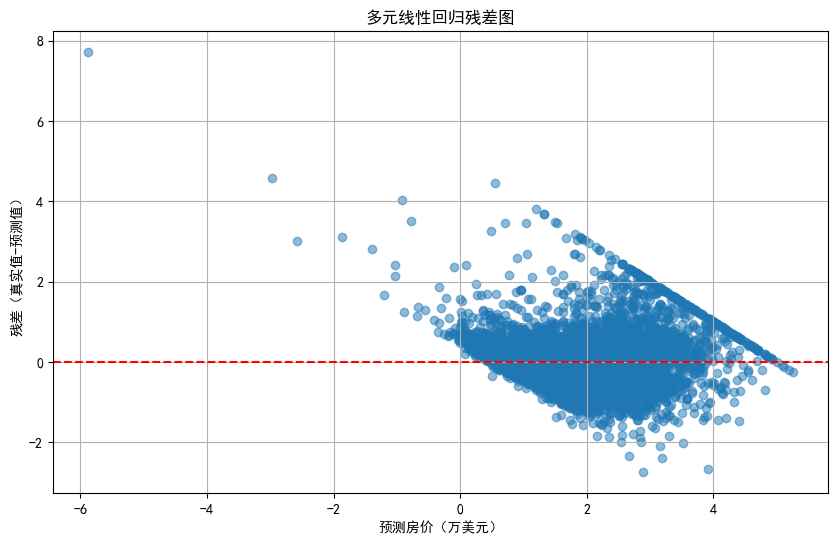

In [24]:
# 1. 初始化并训练模型（使用Scikit-learn，自动处理截距，避免奇异矩阵）
lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)

# 2. 预测
y_pred_multi = lr_multi.predict(X_test)

# 3. 计算评价指标
mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
mae_multi = mean_absolute_error(y_test, y_pred_multi)
r2_multi = r2_score(y_test, y_pred_multi)

# 4. 输出结果
print("=== 多元线性回归模型结果 ===")
print("回归系数（各特征权重）：")
for feat, coef in zip(X.columns, lr_multi.coef_):
    print(f"{feat}: {coef:.4f}")
print(f"截距b：{lr_multi.intercept_:.4f}")
print(f"MSE（测试集）：{mse_multi:.4f}")
print(f"RMSE：{rmse_multi:.4f}")
print(f"MAE：{mae_multi:.4f}")
print(f"R²：{r2_multi:.4f}")

# 5. 可视化残差（验证模型假设）
plt.figure(figsize=(10, 6))
residuals = y_test - y_pred_multi
plt.scatter(y_pred_multi, residuals, alpha=0.5)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("预测房价（万美元）")
plt.ylabel("残差（真实值-预测值）")
plt.title("多元线性回归残差图")
plt.grid(True)
plt.show()

=== 多项式回归模型结果（k=3） ===
回归系数（x, x², x³）：[ 0.71307617  0.04415091 -0.00577021]
截距b：1.9893
模型公式：y = 0.7131x + 0.0442x² + -0.0058x³ + 1.9893
MSE（测试集）：0.6951
RMSE：0.8337
MAE：0.6280
R²：0.4359


D:\Users\13535\anaconda3\envs\pytorch\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


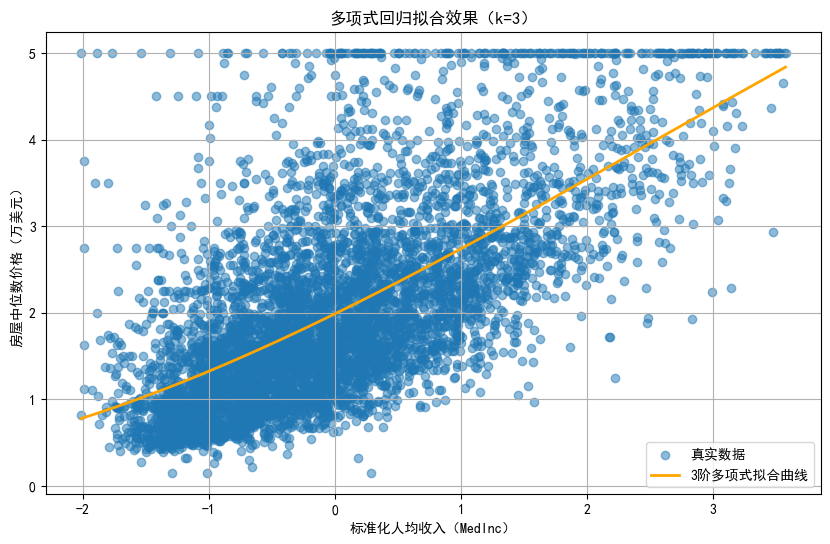

In [25]:
# 1. 多项式特征转换（k=3阶，增加x²、x³项）
poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train[["MedInc"]])
X_test_poly = poly.transform(X_test[["MedInc"]])

# 2. 初始化并训练模型
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)

# 3. 预测
y_pred_poly = lr_poly.predict(X_test_poly)

# 4. 计算评价指标
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

# 5. 输出结果
print("=== 多项式回归模型结果（k=3） ===")
print(f"回归系数（x, x², x³）：{lr_poly.coef_}")
print(f"截距b：{lr_poly.intercept_:.4f}")
print(f"模型公式：y = {lr_poly.coef_[0]:.4f}x + {lr_poly.coef_[1]:.4f}x² + {lr_poly.coef_[2]:.4f}x³ + {lr_poly.intercept_:.4f}")
print(f"MSE（测试集）：{mse_poly:.4f}")
print(f"RMSE：{rmse_poly:.4f}")
print(f"MAE：{mae_poly:.4f}")
print(f"R²：{r2_poly:.4f}")

# 6. 可视化拟合效果（排序后绘制平滑曲线）
X_sort = np.sort(X_test[["MedInc"]], axis=0)
X_sort_poly = poly.transform(X_sort)
y_pred_sort = lr_poly.predict(X_sort_poly)

plt.figure(figsize=(10, 6))
plt.scatter(X_test[["MedInc"]], y_test, alpha=0.5, label="真实数据")
plt.plot(X_sort, y_pred_sort, color="orange", linewidth=2, label="3阶多项式拟合曲线")
plt.xlabel("标准化人均收入（MedInc）")
plt.ylabel("房屋中位数价格（万美元）")
plt.title("多项式回归拟合效果（k=3）")
plt.legend()
plt.grid(True)
plt.show()